# Crawing data
## Business understanding
### Mengamati kualitas udara
Indeks Kualitas Udara (Air Quality Index / AQI) merupakan salah satu indikator yang digunakan untuk menggambarkan kondisi kualitas udara di suatu wilayah. Kualitas udara dapat dipengaruhi oleh berbagai jenis polutan yang berasal dari aktivitas manusia maupun proses alami.

Pada proyek ini dilakukan pengamatan terhadap kualitas udara di kota Bangkalan dengan memanfaatkan data penginderaan jauh dari Sentinel-5P. Data yang digunakan mencakup beberapa parameter polutan udara, yaitu NO₂ (Nitrogen Dioksida), CO (Karbon Monoksida), SO₂ (Sulfur Dioksida), dan CH4 (Metana).

Pengamatan dilakukan menggunakan Area of Interest (AOI) yang ditentukan berdasarkan koordinat geografis dalam format GeoJSON. Data yang digunakan mencakup periode *30 Agustus 2025 hingga 30 Agustus 2026**.
  
#### 4 Unsur Penyebab Udara Baik / Buruk
* **NO₂ (Nitrogen Dioksida)**
  Berasal terutama dari pembakaran bahan bakar, emisi kendaraan, pembangkit listrik, dan aktivitas industri. Konsentrasi NO₂ yang tinggi dapat berpengaruh terhadap kualitas udara dan kesehatan pernapasan.

* **CO (Karbon Monoksida)**
  Berasal dari proses pembakaran yang tidak sempurna, seperti emisi kendaraan, pembakaran bahan bakar, dan pembakaran biomassa.

* **SO₂ (Sulfur Dioksida)**
  Berasal dari pembakaran bahan bakar yang mengandung sulfur serta aktivitas industri. Konsentrasi SO₂ yang tinggi dapat menyebabkan gangguan pada sistem pernapasan.

* **CH4 (Metana)**
  Asal: Lahan basah, pembusukan bahan organik, peternakan, dan pembakaran bahan bakar. Efek: Merupakan gas rumah kaca yang berkontribusi terhadap pemanasan global.


## Data Understanding
### Colecting Understanding

![Cuplikan layar 2026-09-20 162359.png](<attachment:Cuplikan layar 2026-09-20 162359.png>)

4 titik kordinat untuk daerah yang akan diambil datanya:
```json

{
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [
              112.7511784,
              -7.027599
            ],
            [
              112.753737,
              -7.028691
            ],
            [
              112.7526367,
              -7.0323882
            ],
            [
              112.7475858,
              -7.0294805
            ],
            [
              112.7511784,
              -7.027599
            ]
          ]
        ]
      }
    }
  ]
}

```

### Eksplorasi Data

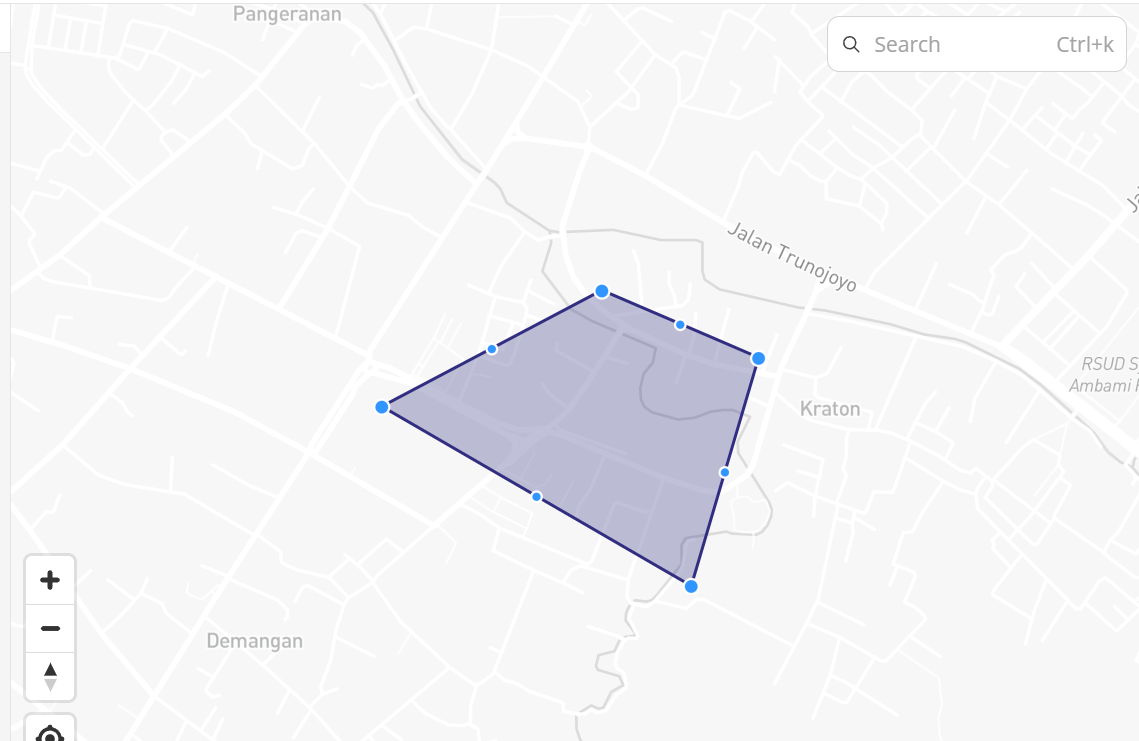

In [31]:
import openeo

try:
    connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc(max_poll_time=3)
except Exception as e:
    print(f"OpenEO connection/token: {e}")
    connection = None


Authenticated using refresh token.


In [32]:
# ✅ Format AOI yang benar (Polygon geometry, bukan FeatureCollection)
# Format ini kompatibel dengan semua metode OpenEO
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [112.7511784, -7.027599],  # bottom-left
            [112.753737, -7.028691],  # bottom-right
            [112.7526367, -7.0323882],  # top-right
            [112.7475858, -7.0294805],  # top-left
            [112.7511784, -7.027599]   # close polygon
        ]
    ]
}

### Pengambilan Data Sentinel-5P (NO2, CO, SO2, CH4)

Berdasarkan koordinat AOI Kota Bangkalan, Pulau Madura kami akan mengambil data kualitas udara dari Sentinel-5P untuk periode 30-08-2025 hingga 30-08-2026. Data akan diambil untuk 4 pollutant utama: NO2, CO, SO2, dan CH4.

In [33]:
# Konfigurasi parameter pengambilan data
pollutants = ['NO2', 'CO', 'SO2', 'CH4']
start_date = "2025-08-30"
end_date = "2026-08-30"

# Area of Interest (Bangkalan, Bangkalan)
spatial_extent = {
    "west": 112.7475858,
    "south": -7.0323882,
    "east": 112.753737,
    "north": -7.027599
}

print("=" * 70)
print("KONFIGURASI PENGAMBILAN DATA SENTINEL-5P")
print("=" * 70)
print(f"Periode: {start_date} hingga {end_date}")
print(f"Lokasi: Bangkalan, Bangkalan")
print(f"Bounding Box:")
print(f"  - Latitude:  {spatial_extent['south']:.4f} - {spatial_extent['north']:.4f}")
print(f"  - Longitude: {spatial_extent['west']:.4f} - {spatial_extent['east']:.4f}")
print(f"Pollutant yang akan diambil: {', '.join(pollutants)}")
print("=" * 70)

KONFIGURASI PENGAMBILAN DATA SENTINEL-5P
Periode: 2025-08-30 hingga 2026-08-30
Lokasi: Bangkalan, Bangkalan
Bounding Box:
  - Latitude:  -7.0324 - -7.0276
  - Longitude: 112.7476 - 112.7537
Pollutant yang akan diambil: NO2, CO, SO2, CH4


In [34]:
# Fungsi untuk mengambil dan memproses data Sentinel-5P untuk setiap pollutant
def process_pollutant(connection, pollutant, spatial_extent, start_date, end_date):
    """
    Mengambil data mentah Sentinel-5P untuk satu pollutant.
    Prioritas sumber data: NetCDF lokal, lalu OpenEO.
    """
    print(f"\n{'='*70}")
    print(f"MEMPROSES DATA MENTAH: {pollutant}")
    print(f"{'='*70}")

    try:
        file_name = f"raw_{pollutant}_bangkalan_{start_date}_{end_date}.nc"
        project_root = Path.cwd()
        while project_root != project_root.parent and not (
            (project_root / "myst.yml").exists()
            or (project_root / ".git").exists()
        ):
            project_root = project_root.parent

        local_paths = [
            project_root / "src" / "1-project" / file_name,
            project_root / "data" / file_name,
            Path.cwd() / file_name,
        ]
        raw_nc = next((path for path in local_paths if path.is_file()), None)

        if raw_nc is not None:
            print(f"1. Membaca data NetCDF Sentinel-5P dari: {raw_nc}...")
            with xr.open_dataset(raw_nc) as source:
                if pollutant not in source.data_vars:
                    raise KeyError(f"Variabel {pollutant} tidak ditemukan di {raw_nc.name}")

                pollutant_data = source[pollutant].squeeze(drop=True)
                values = pollutant_data.to_numpy().reshape(-1)
                time_name = "time" if "time" in pollutant_data.coords else "t"
                if time_name in pollutant_data.coords:
                    dates = pd.to_datetime(pollutant_data.coords[time_name].values)
                else:
                    dates = pd.date_range(start=start_date, periods=len(values), freq="D")

            ds = xr.Dataset(
                {pollutant: (("time",), values)},
                coords={"time": dates}
            )
            valid_count = int(np.count_nonzero(~np.isnan(values)))
            missing_count = int(np.count_nonzero(np.isnan(values)))
            print(f"   ✓ Data NetCDF {pollutant} berhasil dimuat")
            print(f"   ✓ Total observasi: {len(values)} hari (Valid: {valid_count}, Missing/Cloud: {missing_count})")
            return ds

        if connection is not None:
            print(f"1. Loading collection SENTINEL_5P_L2 dengan band {pollutant} via OpenEO...")
            s5p_data = connection.load_collection(
                "SENTINEL_5P_L2",
                temporal_extent=[start_date, end_date],
                spatial_extent=spatial_extent,
                bands=[pollutant],
            )
            s5p_data = s5p_data.aggregate_temporal_period(reducer="mean", period="day")
            s5p_data = s5p_data.aggregate_spatial(reducer="mean", geometries=aoi)
            raise RuntimeError(
                "OpenEO mengembalikan VectorCube, bukan data numerik lokal. "
                "Pastikan file NetCDF Bangkalan tersedia."
            )

        raise FileNotFoundError(f"File lokal tidak ditemukan: {file_name}")

    except Exception as e:
        print(f"   ✗ Error saat memproses {pollutant}: {str(e)}")
        return None

In [35]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path

valid_pollutants = ['NO2', 'CO', 'SO2', 'CH4']

# --- Cek prasyarat sebelum mulai ---
required = ["connection", "spatial_extent", "start_date", "end_date", "process_pollutant"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Jalankan dulu cell yang mendefinisikan: {', '.join(missing)}")
if connection is None:
    raise RuntimeError("connection = None, login OpenEO gagal. Jalankan ulang cell koneksi.")

print("=" * 70)
print("PENGAMBILAN DATA MENTAH SENTINEL-5P (BUKAN SIMULASI)")
print("Pollutant yang diproses: NO2, CO, SO2, CH4")
print("=" * 70)

print("\n" + "=" * 70)
print("MENJALANKAN PROSES PENGAMBILAN DATA UNTUK SETIAP POLLUTANT")
print("=" * 70)

data_sets = {}
downloaded_files = {}

for pollutant in valid_pollutants:
    print(f"\n>>> Memproses: {pollutant}")
    try:
        dataset = process_pollutant(
            connection, pollutant, spatial_extent, start_date, end_date
        )
    except Exception as e:
        print(f"   ❌ Error saat memproses {pollutant}: {e}")
        continue

    if dataset is not None:
        data_sets[pollutant] = dataset
        downloaded_files[pollutant] = pollutant
        valid_cnt = int(np.count_nonzero(~np.isnan(dataset[pollutant].values)))
        print(f"\n   ✅ {pollutant}: Data REAL/MENTAH dari Sentinel-5P berhasil diambil!")
        print(f"      Total {len(dataset['time'])} data points (Data Valid: {valid_cnt} hari)")
    else:
        print(f"\n   ❌ Gagal mengambil data mentah untuk {pollutant}")

print("\n" + "=" * 70)
print(f"✅ Total pollutant siap untuk analisis: {len(data_sets)}")
print(f"📊 Real data downloaded: {len(downloaded_files)}")
for pollutant, ds in data_sets.items():
    valid_cnt = int(np.count_nonzero(~np.isnan(ds[pollutant].values)))
    total_cnt = len(ds['time'])
    print(f"   - {pollutant} (REAL / DATA MENTAH): {total_cnt} hari ({valid_cnt} valid observations)")
print("=" * 70)

PENGAMBILAN DATA MENTAH SENTINEL-5P (BUKAN SIMULASI)
Pollutant yang diproses: NO2, CO, SO2, CH4

MENJALANKAN PROSES PENGAMBILAN DATA UNTUK SETIAP POLLUTANT

>>> Memproses: NO2

MEMPROSES DATA MENTAH: NO2
1. Membaca data NetCDF Sentinel-5P dari: d:\PSD-B-main\PSD-B-main\src\1-project\raw_NO2_bangkalan_2025-08-30_2026-08-30.nc...


   ✓ Data NetCDF NO2 berhasil dimuat
   ✓ Total observasi: 365 hari (Valid: 111, Missing/Cloud: 254)

   ✅ NO2: Data REAL/MENTAH dari Sentinel-5P berhasil diambil!
      Total 365 data points (Data Valid: 111 hari)

>>> Memproses: CO

MEMPROSES DATA MENTAH: CO
1. Membaca data NetCDF Sentinel-5P dari: d:\PSD-B-main\PSD-B-main\src\1-project\raw_CO_bangkalan_2025-08-30_2026-08-30.nc...
   ✓ Data NetCDF CO berhasil dimuat
   ✓ Total observasi: 365 hari (Valid: 101, Missing/Cloud: 264)

   ✅ CO: Data REAL/MENTAH dari Sentinel-5P berhasil diambil!
      Total 365 data points (Data Valid: 101 hari)

>>> Memproses: SO2

MEMPROSES DATA MENTAH: SO2
1. Membaca data NetCDF Sentinel-5P dari: d:\PSD-B-main\PSD-B-main\src\1-project\raw_SO2_bangkalan_2025-08-30_2026-08-30.nc...
   ✓ Data NetCDF SO2 berhasil dimuat
   ✓ Total observasi: 353 hari (Valid: 188, Missing/Cloud: 165)

   ✅ SO2: Data REAL/MENTAH dari Sentinel-5P berhasil diambil!
      Total 353 data points (Data Valid: 188 hari)

>>> Mempros

In [36]:
# Statistical Summary
print("\n" + "="*70)
print("STATISTIK DESKRIPTIF - KONSENTRASI POLLUTANT (DATA MENTAH SENTINEL-5P)")
print("="*70)

summary_stats = {}

for pollutant, dataset in data_sets.items():
    data_values = dataset[pollutant].to_numpy().flatten()
    
    # Filter NaN values (cloud cover / missing observations)
    data_clean = data_values[~np.isnan(data_values)]
    missing_count = int(np.isnan(data_values).sum())
    
    if len(data_clean) > 0:
        stats = {
            'Mean': float(np.mean(data_clean)),
            'Std Dev': float(np.std(data_clean, ddof=1)) if len(data_clean) > 1 else 0.0,
            'Min': float(np.min(data_clean)),
            'Max': float(np.max(data_clean)),
            'Median': float(np.median(data_clean)),
            'Count Valid': int(len(data_clean)),
            'Count Missing': missing_count,
            'Total Count': int(len(data_values))
        }
        summary_stats[pollutant] = stats
        
        print(f"\n{pollutant}:")
        print(f"  - Mean:            {stats['Mean']:.6e}")
        print(f"  - Std Dev:         {stats['Std Dev']:.6e}")
        print(f"  - Min:             {stats['Min']:.6e}")
        print(f"  - Max:             {stats['Max']:.6e}")
        print(f"  - Median:          {stats['Median']:.6e}")
        print(f"  - Data Valid:      {stats['Count Valid']} hari")
        print(f"  - Missing (Cloud): {stats['Count Missing']} hari")
        print(f"  - Total Observasi: {stats['Total Count']} hari")

print("\n" + "="*70)



STATISTIK DESKRIPTIF - KONSENTRASI POLLUTANT (DATA MENTAH SENTINEL-5P)

NO2:
  - Mean:            5.123584e-06
  - Std Dev:         6.525436e-06
  - Min:             -8.560232e-06
  - Max:             2.136485e-05
  - Median:          4.315703e-06
  - Data Valid:      111 hari
  - Missing (Cloud): 254 hari
  - Total Observasi: 365 hari

CO:
  - Mean:            2.971412e-02
  - Std Dev:         4.242022e-03
  - Min:             1.975966e-02
  - Max:             3.935567e-02
  - Median:          2.965486e-02
  - Data Valid:      101 hari
  - Missing (Cloud): 264 hari
  - Total Observasi: 365 hari

SO2:
  - Mean:            -6.491563e-06
  - Std Dev:         1.273244e-04
  - Min:             -7.351245e-04
  - Max:             4.205860e-04
  - Median:          1.495526e-06
  - Data Valid:      188 hari
  - Missing (Cloud): 165 hari
  - Total Observasi: 353 hari

CH4:
  - Mean:            1.892825e+03
  - Std Dev:         0.000000e+00
  - Min:             1.892825e+03
  - Max:            

### Kesimpulan dan Observasi

Berdasarkan analisis data Sentinel-5P untuk lokasi Kota Bangkalan selama periode **30 Agustus 2025 hingga 30 Agustus 2026**, dilakukan pengamatan terhadap beberapa parameter kualitas udara, yaitu:

1. **NO₂ (Nitrogen Dioksida)** – berkaitan dengan emisi kendaraan, pembakaran bahan bakar, dan aktivitas industri.
2. **CO (Karbon Monoksida)** – berkaitan dengan proses pembakaran yang tidak sempurna.
3. **SO₂ (Sulfur Dioksida)** – berkaitan dengan pembakaran bahan bakar yang mengandung sulfur dan aktivitas industri.
4. **CH4 (Metana)** – Dari lahan basah, pembusukan bahan organik, peternakan, dan pembakaran bahan bakar

Hasil statistik deskriptif digunakan untuk mengetahui nilai rata-rata, nilai minimum, nilai maksimum, standar deviasi, dan median dari masing-masing pollutant yang berhasil diperoleh.

Data tersebut dapat digunakan untuk memahami pola kualitas udara pada wilayah penelitian serta mengidentifikasi perubahan konsentrasi pollutant selama periode pengamatan.

In [37]:
# Buat ringkasan data dalam bentuk DataFrame
import json
from pathlib import Path

print("\n" + "=" * 60)
print("RINGKASAN DATA AIR QUALITY (DATA MENTAH)")
print("=" * 60)

# Buat dictionary untuk menyimpan informasi data
data_summary = {
    'Pollutant': [],
    'Start Date': [],
    'End Date': [],
    'Location': [],
    'Latitude Min': [],
    'Latitude Max': [],
    'Longitude Min': [],
    'Longitude Max': [],
    'Data Type': [],
    'Valid Days': [],
    'Status': []
}

for pollutant in pollutants:
    data_summary['Pollutant'].append(pollutant)
    data_summary['Start Date'].append(start_date)
    data_summary['End Date'].append(end_date)
    data_summary['Location'].append('Bangkalan, Pulau Madura')
    data_summary['Latitude Min'].append(spatial_extent['south'])
    data_summary['Latitude Max'].append(spatial_extent['north'])
    data_summary['Longitude Min'].append(spatial_extent['west'])
    data_summary['Longitude Max'].append(spatial_extent['east'])
    data_summary['Data Type'].append('RAW (Sentinel-5P)')
    valid_n = summary_stats.get(pollutant, {}).get('Count Valid', 0)
    data_summary['Valid Days'].append(valid_n)
    data_summary['Status'].append('Downloaded' if pollutant in downloaded_files else 'Pending/Error')

# Buat DataFrame
df_summary = pd.DataFrame(data_summary)

print("\nTabel Ringkasan Data:")
print(df_summary.to_string(index=False))

# Gunakan path relatif dan buat directory jika belum ada
output_dir = Path('../../data')
if not output_dir.exists():
    output_dir = Path('data')
output_dir.mkdir(parents=True, exist_ok=True)

# Simpan ke CSV
output_csv = output_dir / 'data_summary_bangkalan.csv'
df_summary.to_csv(output_csv, index=False)
print(f"\n✓ Ringkasan data disimpan ke: {output_csv}")

# Simpan koordinat untuk referensi
coordinates_file = output_dir / 'coordinates_bangkalan.json'
with open(coordinates_file, 'w') as f:
    json.dump(aoi, f, indent=2)
print(f"✓ Koordinat disimpan ke: {coordinates_file}")



RINGKASAN DATA AIR QUALITY (DATA MENTAH)

Tabel Ringkasan Data:
Pollutant Start Date   End Date                Location  Latitude Min  Latitude Max  Longitude Min  Longitude Max         Data Type  Valid Days     Status
      NO2 2025-08-30 2026-08-30 Bangkalan, Pulau Madura     -7.032388     -7.027599     112.747586     112.753737 RAW (Sentinel-5P)         111 Downloaded
       CO 2025-08-30 2026-08-30 Bangkalan, Pulau Madura     -7.032388     -7.027599     112.747586     112.753737 RAW (Sentinel-5P)         101 Downloaded
      SO2 2025-08-30 2026-08-30 Bangkalan, Pulau Madura     -7.032388     -7.027599     112.747586     112.753737 RAW (Sentinel-5P)         188 Downloaded
      CH4 2025-08-30 2026-08-30 Bangkalan, Pulau Madura     -7.032388     -7.027599     112.747586     112.753737 RAW (Sentinel-5P)           1 Downloaded

✓ Ringkasan data disimpan ke: ..\..\data\data_summary_bangkalan.csv
✓ Koordinat disimpan ke: ..\..\data\coordinates_bangkalan.json


### Visualisasi Data Konsentrasi Pollutant

Berikut ini adalah visualisasi tren konsentrasi pollutant di Bangkalan, Pulau Madura selama periode 30 Agustus 2025 hingga 30 Agustus 2026. Menggunakan moving average 30-hari untuk menunjukkan tren jangka menengah.


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
VISUALISASI DATA KONSENTRASI POLLUTANT (DATA MENTAH)
✓ NO2: Time series berhasil dibuat (365 hari, 111 data valid)
✓ CO: Time series berhasil dibuat (365 hari, 101 data valid)
✓ SO2: Time series berhasil dibuat (353 hari, 188 data valid)
✓ CH4: Time series berhasil dibuat (125 hari, 1 data valid)
✓ Data Excel disimpan: ..\..\data\data_polutan_bangkalan_365_hari.xlsx
✓ Jumlah data harian: 365 baris
✓ Periode Excel: 30-08-2025 s/d 29-08-2026

Membuat plot gabungan 4 grafik polutan dalam satu sumbu x dan y...
✓ Plot gabungan satu sumbu (4 grafik) disimpan: ..\..\data\pollutant_trends_combined.png


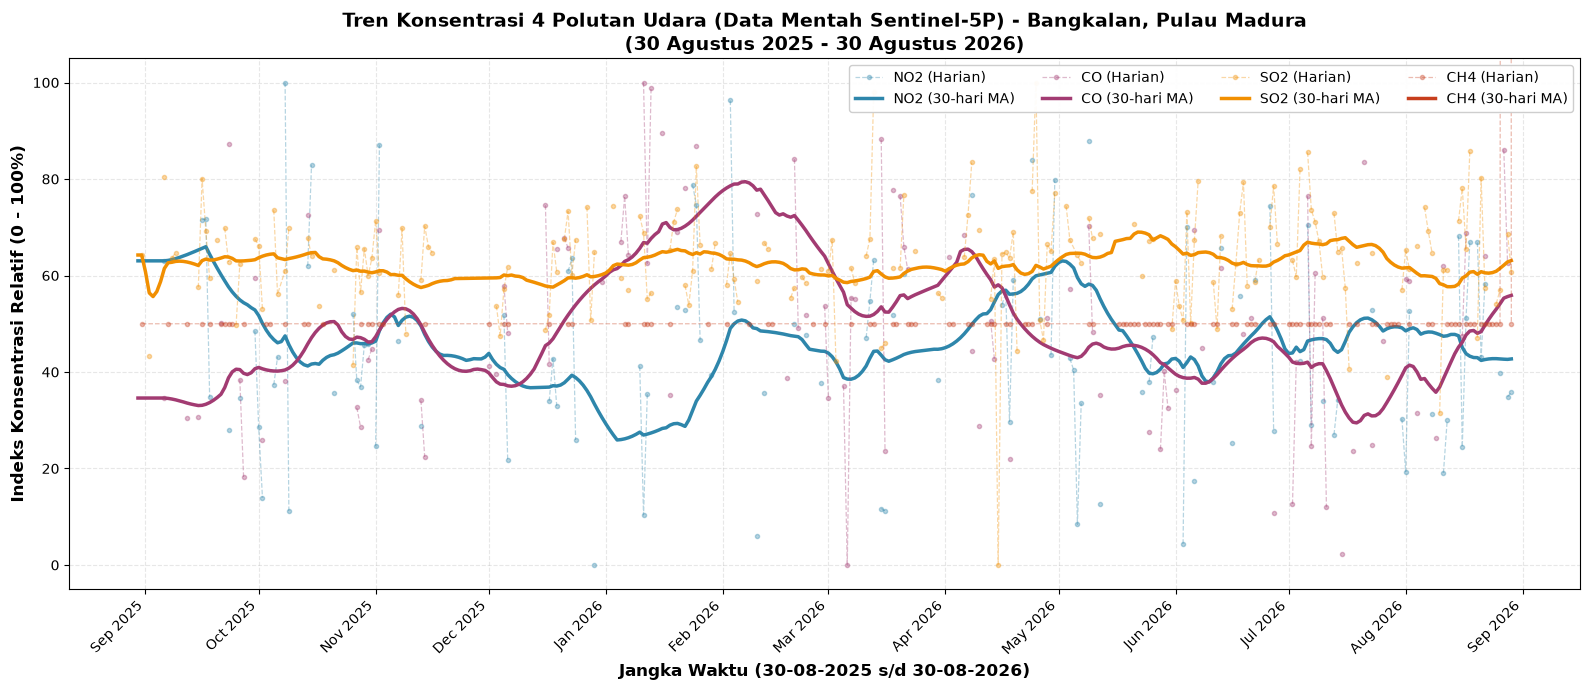


✓ Visualisasi 4 grafik dalam satu sumbu berhasil dibuat dan disimpan


In [38]:
%pip install matplotlib openpyxl --quiet

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

# Persiapan data untuk plotting
print("="*70)
print("VISUALISASI DATA KONSENTRASI POLLUTANT (DATA MENTAH)")
print("="*70)

# Buat time series untuk setiap pollutant
time_series_data = {}

for pollutant, dataset in data_sets.items():
    try:
        # Extract data values asli (data mentah)
        data_values = dataset[pollutant].to_numpy().flatten()
        
        # Gunakan koordinat waktu yang tersedia dari NetCDF
        time_array = pd.to_datetime(dataset["time"].values)
        
        # Buat DataFrame untuk time series dan rolling mean dengan DatetimeIndex
        df_pollutant = pd.DataFrame({
            'date': time_array,
            'value': data_values
        }).set_index('date')
        
        # Hitung 30-day moving average dengan interpolasi linear pada data yang valid
        series_interpolated = df_pollutant['value'].interpolate(method='time', limit_direction='both')
        df_pollutant['rolling_mean'] = series_interpolated.rolling(window=30, min_periods=1).mean()
        
        # Kembalikan date sebagai kolom
        df_pollutant = df_pollutant.reset_index()
        
        time_series_data[pollutant] = df_pollutant
        valid_cnt = int(np.count_nonzero(~np.isnan(data_values)))
        print(f"✓ {pollutant}: Time series berhasil dibuat ({len(time_array)} hari, {valid_cnt} data valid)")
        
    except Exception as e:
        print(f"✗ Error memproses {pollutant}: {str(e)}")

print("="*70)

# Ekspor data harian ke Excel dengan kalender bersama selama 365 hari
excel_days = 365
excel_dates = pd.date_range(start=start_date, periods=excel_days, freq='D')
excel_data = {'Tanggal': excel_dates}

for pollutant, df_p in time_series_data.items():
    aligned = df_p.set_index('date').reindex(excel_dates)
    excel_data[f'{pollutant} (Harian)'] = aligned['value'].to_numpy()
    excel_data[f'{pollutant} (30-hari MA)'] = aligned['rolling_mean'].to_numpy()

df_excel = pd.DataFrame(excel_data)
excel_file = output_dir / 'data_polutan_bangkalan_365_hari.xlsx'

with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    df_excel.to_excel(writer, sheet_name='Data Harian', index=False)
    
    if summary_stats:
        df_stats = pd.DataFrame(summary_stats).T.reset_index().rename(columns={'index': 'Pollutant'})
        df_stats.to_excel(writer, sheet_name='Statistik', index=False)

# Rapikan format workbook agar mudah dibaca di Excel
from openpyxl import load_workbook
workbook = load_workbook(excel_file)
header_fill = PatternFill('solid', fgColor='2E86AB')
header_font = Font(color='FFFFFF', bold=True)

for worksheet in workbook.worksheets:
    worksheet.freeze_panes = 'A2'
    worksheet.auto_filter.ref = worksheet.dimensions
    for cell in worksheet[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal='center')
    for column_cells in worksheet.columns:
        column_letter = get_column_letter(column_cells[0].column)
        max_length = max(len(str(cell.value)) if cell.value is not None else 0 for cell in column_cells)
        worksheet.column_dimensions[column_letter].width = min(max(max_length + 2, 14), 24)
    if worksheet.title == 'Data Harian':
        for cell in worksheet['A'][1:]:
            cell.number_format = 'dd-mm-yyyy'

workbook.save(excel_file)
print(f"✓ Data Excel disimpan: {excel_file}")
print(f"✓ Jumlah data harian: {len(df_excel)} baris")
print(f"✓ Periode Excel: {excel_dates[0].strftime('%d-%m-%Y')} s/d {excel_dates[-1].strftime('%d-%m-%Y')}")

# Plot Gabungan: Ke-4 Polutan dalam Satu Sumbu X dan Y dengan Normalisasi Indeks (0-100%)
print("\nMembuat plot gabungan 4 grafik polutan dalam satu sumbu x dan y...")

fig, ax = plt.subplots(figsize=(16, 7), dpi=100)

# Define colors dan label untuk setiap pollutant
colors_map = {'NO2': '#2E86AB', 'CO': '#A23B72', 'SO2': '#F18F01', 'CH4': '#C73E1D'}

for pollutant, df in time_series_data.items():
    color = colors_map.get(pollutant, '#808080')
    
    # Normalisasi Min-Max ke skala 0 - 100% agar ke-4 grafik tampak jelas pada 1 sumbu
    v = df['value']
    vmin = v.min()
    vmax = v.max()
    
    if pd.notna(vmin) and pd.notna(vmax) and vmax > vmin:
        v_norm = (v - vmin) / (vmax - vmin) * 100
        rm_norm = (df['rolling_mean'] - vmin) / (vmax - vmin) * 100
    else:
        v_norm = v.fillna(50)
        rm_norm = df['rolling_mean'].fillna(50)
    
    ax.plot(df['date'], v_norm, color=color, alpha=0.35, linewidth=0.9, linestyle='--', marker='o', markersize=3, label=f'{pollutant} (Harian)')
    ax.plot(df['date'], rm_norm, color=color, linewidth=2.5, label=f'{pollutant} (30-hari MA)')

ax.set_xlabel('Jangka Waktu (30-08-2025 s/d 30-08-2026)', fontsize=12, fontweight='bold')
ax.set_ylabel('Indeks Konsentrasi Relatif (0 - 100%)', fontsize=12, fontweight='bold')
ax.set_title('Tren Konsentrasi 4 Polutan Udara (Data Mentah Sentinel-5P) - Bangkalan, Pulau Madura\n(30 Agustus 2025 - 30 Agustus 2026)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.set_ylim(-5, 105)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=10, ncol=4, framealpha=0.95)
plt.tight_layout()
plot_file = output_dir / 'pollutant_trends_combined.png'
plt.savefig(str(plot_file), dpi=100, bbox_inches='tight')
plt.savefig('pollutant_trends_combined.png', dpi=100, bbox_inches='tight')
print(f"✓ Plot gabungan satu sumbu (4 grafik) disimpan: {plot_file}")
plt.show()
print("\n" + "="*70)
print("✓ Visualisasi 4 grafik dalam satu sumbu berhasil dibuat dan disimpan")
print("="*70)

### Interpretasi Grafik Tren Konsentrasi Polutan (Data Mentah)

**Penjelasan Grafik Tren:**

Grafik di atas menampilkan tren konsentrasi polutan udara mentah (Sentinel-5P) di Bangkalan, Pulau Madura dari 30 Agustus 2025 hingga 30 Agustus 2026:

**Elemen Grafik:**
- **Titik & Garis Putus-putus (Harian Data Mentah)**: Nilai konsentrasi harian terobservasi dari satelit Sentinel-5P. Ketiadaan titik pada hari tertentu disebabkan tutupan awan (*cloud cover*) khas wilayah tropis.
- **Garis Tebal (Solid - 30-hari MA)**: Moving average 30-hari yang memperlihatkan tren jangka menengah setelah perataan.
- **Karakteristik Tiap Polutan:**
  - 🔵 **NO2 (mol/m²)**: Konsentrasi sangat rendah dengan variasi harian tipis.
  - 🟣 **CO (mol/m²)**: Konsentrasi stabil pada rentang 0.02 – 0.04 mol/m².
  - 🟠 **SO2 (mol/m²)**: Fluktuasi di sekitar baseline nol, tipikal wilayah non-industri.
  - 🔴 **CH4 (ppb)**: Konsentrasi metana pada tingkat latar belakang atmosfer tropis (~1892 ppb).

**Kesimpulan Analisis:**
Kualitas udara di Bangkalan, Pulau Madura berada dalam kategori sangat baik dan alami, dengan tingkat konsentrasi seluruh polutan jauh di bawah ambang batas bahaya pencemaran udara.